<center> <h1 style="background-color:DarkSlateBlue; color:white" >A/B Testing: Step by Step & Hypothesis Testing</h1> 

<center><img
src="https://tactilegames.com/wp-content/uploads/2023/03/TT_Header_CookieCats_UW_Up-scaled.webp" style="width:40%;height:40%;">
</center>
    
<br>    
    
<div class="list-group" id="list-tab" role="tablist">
  <h3 class="list-group-item list-group-item-action active" style="background-color:DarkSlateBlue; color:white" data-toggle="list"  role="tab" aria-controls="home">Notebook Content!</h3>  
  <a class="list-group-item list-group-item-action" data-toggle="list" href="#libraries" role="tab" aria-controls="profile" style="color:DarkSlateBlue">Import Libraries<span class="badge badge-primary badge-pill" style="background-color:DarkSlateBlue; color:white">1</span></a>
  <a id="section2" class="list-group-item list-group-item-action" data-toggle="list" href="#load" role="tab" aria-controls="messages" style="color:DarkSlateBlue">Load Data<span class="badge badge-primary badge-pill" style="background-color:DarkSlateBlue; color:white">2</span></a>
  <a id="section2" class="list-group-item list-group-item-action" data-toggle="list" href="#summary" role="tab" aria-controls="messages" style="color:DarkSlateBlue">Summary Stats<span class="badge badge-primary badge-pill" style="background-color:DarkSlateBlue; color:white">3</span></a>
  <a id="section2" class="list-group-item list-group-item-action" data-toggle="list" href="#outliers" role="tab" aria-controls="messages" style="color:DarkSlateBlue">Outliers<span class="badge badge-primary badge-pill" style="background-color:DarkSlateBlue; color:white">4</span></a>
  <a id="section2" class="list-group-item list-group-item-action" data-toggle="list" href="#details" role="tab" aria-controls="messages" style="color:DarkSlateBlue">Some Details<span class="badge badge-primary badge-pill" style="background-color:DarkSlateBlue; color:white">5</span></a>
  <a id="section2" class="list-group-item list-group-item-action" data-toggle="list" href="#ab" role="tab" aria-controls="messages" style="color:DarkSlateBlue">A/B Testing<span class="badge badge-primary badge-pill" style="background-color:DarkSlateBlue; color:white">6</span></a>   <a id="section2" class="list-group-item list-group-item-action" data-toggle="list" href="#conclusion" role="tab" aria-controls="messages" style="color:DarkSlateBlue">Conclusion<span class="badge badge-primary badge-pill" style="background-color:DarkSlateBlue; color:white">7</span></a>

### Project Description from [**DataCamp**](https://www.datacamp.com/projects/184)

Cookie Cats is a hugely popular mobile puzzle game developed by Tactile Entertainment. It's a classic "connect three" style puzzle game where the player must connect tiles of the same color in order to clear the board and win the level. It also features singing cats. We're not kidding!

**As players progress through the game they will encounter gates that force them to wait some time before they can progress or make an in-app purchase. In this project, we will analyze the result of an A/B test where the first gate in Cookie Cats was moved from level 30 to level 40. In particular, we will analyze the impact on player retention and game rounds**.


<center><iframe width="560" height="315" src="https://www.youtube.com/embed/0G-612U2vQY" frameborder="0" allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture" allowfullscreen></iframe></iframe></center>


### Data Description from [**Aurelia Sui's notebook**](https://www.kaggle.com/yufengsui/datacamp-project-mobile-games-a-b-testing)

<p>The data is from 90,189 players that installed the game while the AB-test was running. The variables are:</p>
<ul>
<li><code>userid</code> - a unique number that identifies each player.</li>
<li><code>version</code> - whether the player was put in the control group (<code>gate_30</code> - a gate at level 30) or the test group (<code>gate_40</code> - a gate at level 40).</li>
<li><code>sum_gamerounds</code> - the number of game rounds played by the player during the first week after installation
<li><code>retention_1</code> - did the player come back and play 1 day after installing?</li>
<li><code>retention_7</code> - did the player come back and play 7 days after installing?</li>
</ul>
<p>When a player installed the game, he or she was randomly assigned to either <code>gate_30</code> or <code>gate_40</code>. </p>

### AB Testing Process

1. Understanding business problem & data
2. Detect and resolve problems in the data (Missing Value, Outliers, Unexpected Value)
3. Look summary stats and plots
4. Apply hypothesis testing and check assumptions
    - Check Normality & Homogeneity
    - Apply tests (Shapiro, Levene Test, T-Test, Welch Test, Mann Whitney U Test)
5. Evaluate the results
6. Make inferences 
7. Recommend business decision to your customer/director/ceo etc. 

<a id='libraries'></a>
<h1 style="color:DarkSlateBlue" >1. PACKAGES</h1>

In [1]:
# Base
# -----------------------------------
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt


# Hypothesis Testing
# -----------------------------------
from scipy.stats import shapiro
import scipy.stats as stats

# Configuration
# -----------------------------------
import warnings
warnings.filterwarnings("ignore")
warnings.simplefilter(action='ignore', category=FutureWarning)

pd.set_option('display.max_columns', None)

<a id='load'></a>
<h1 style="color:DarkSlateBlue" >2. DATA</h1>

In [2]:
ab = pd.read_csv('cookie_cats.csv')
ab

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True
...,...,...,...,...,...
90184,9999441,gate_40,97,True,False
90185,9999479,gate_40,30,False,False
90186,9999710,gate_30,28,True,False
90187,9999768,gate_40,51,True,False


<a id='summary'></a>
<h1 style="color:DarkSlateBlue" >3. SUMMARY STATS</h1>

In [3]:
# Verifying if there is only unique userids
print(ab.userid.nunique() == ab.shape[0])
# Summary Stats: sum_gamerounds
ab['sum_gamerounds'].describe()

True


count    90189.000000
mean        51.872457
std        195.050858
min          0.000000
25%          5.000000
50%         16.000000
75%         51.000000
max      49854.000000
Name: sum_gamerounds, dtype: float64

In [4]:
# A/B Groups & Target Summary Stats
ab.groupby("version")['sum_gamerounds'].describe()

,count,mean,std,min,25%,50%,75%,max
version,,,,,,,,
gate_30,44700.0,52.456264,256.716423,0.0,5.0,17.0,50.0,49854.0
gate_40,45489.0,51.298776,103.294416,0.0,5.0,16.0,52.0,2640.0


<Axes: xlabel='version', ylabel='sum_gamerounds'>

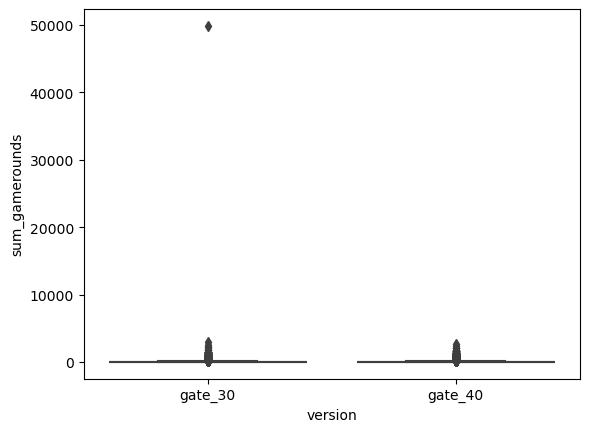

In [5]:
# We need to remove some outliers!!
sns.boxplot(data=ab, y='sum_gamerounds', x='version')

In [6]:
# Lot of players have never played the game or played just a few rounds!!
# We can see that the numbers of users decreases as levels progress!!
ab['sum_gamerounds'].value_counts().sort_index()[0:10]

sum_gamerounds
0    3994
1    5538
2    4606
3    3958
4    3629
5    2992
6    2861
7    2379
8    2267
9    2013
Name: count, dtype: int64

<Axes: xlabel='sum_gamerounds'>

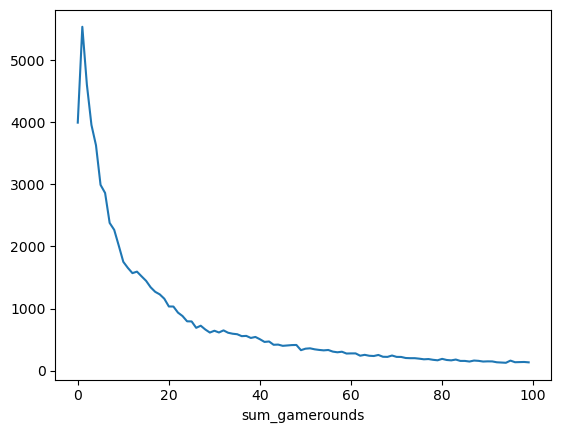

In [7]:
ab['sum_gamerounds'].value_counts().sort_index()[0:100].plot()

In [8]:
# Number of persons that have never played the game
ab[ab['sum_gamerounds']==0].shape[0]

3994

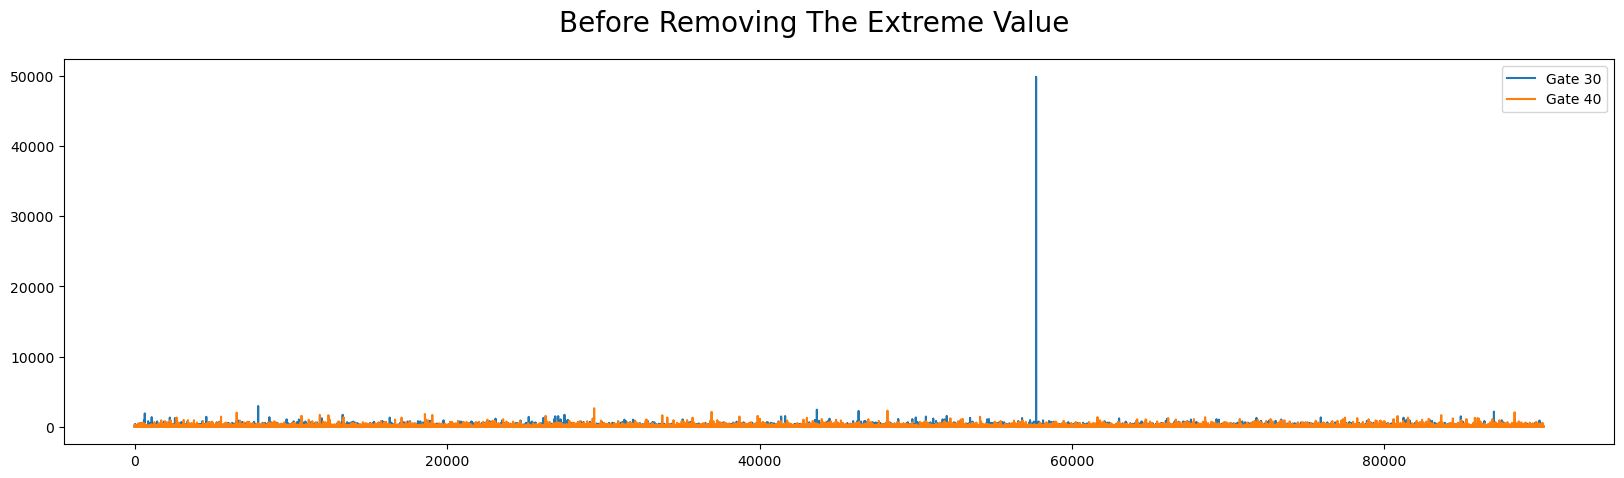

In [9]:
# We really need to remove the outliers!!
ab[ab.version == "gate_30"].sum_gamerounds.plot(legend = True, label = "Gate 30", figsize = (20,5))
ab[ab.version == "gate_40"].sum_gamerounds.plot(legend = True, label = "Gate 40")
plt.suptitle("Before Removing The Extreme Value", fontsize = 20);

<a id='outliers'></a>
<h1 style="color:DarkSlateBlue" >4. OUTLIERS</h1>

In [10]:
# Removing only the biggest outlier
ab = ab[ab.sum_gamerounds < ab.sum_gamerounds.max()]

# Summary Stats: sum_gamerounds
ab['sum_gamerounds'].describe()

count    90188.000000
mean        51.320253
std        102.682719
min          0.000000
25%          5.000000
50%         16.000000
75%         51.000000
max       2961.000000
Name: sum_gamerounds, dtype: float64

Text(0.5, 1.0, 'After Removing The Extreme Value')

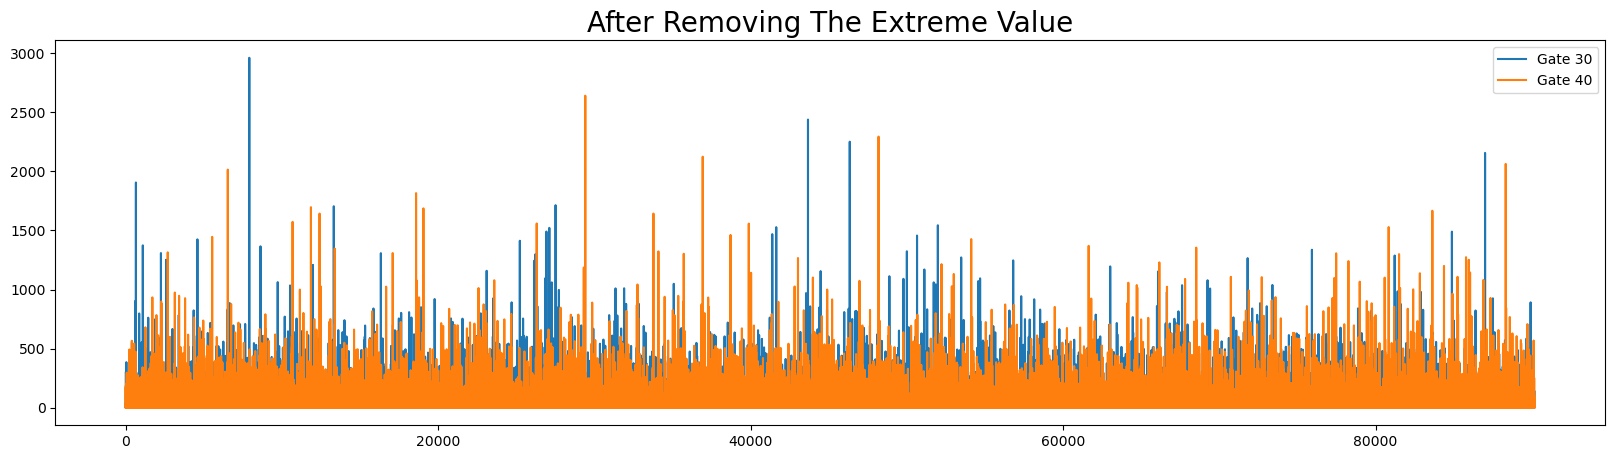

In [11]:
# The line graph after removing the biggest outlier!
ab[ab['version'] == 'gate_30']['sum_gamerounds'].plot(legend=True, label='Gate 30', figsize=(20, 5))
ab[ab['version'] == 'gate_40']['sum_gamerounds'].plot(legend=True, label='Gate 40', figsize=(20, 5))
plt.title('After Removing The Extreme Value', fontsize = 20)

<Axes: xlabel='version', ylabel='sum_gamerounds'>

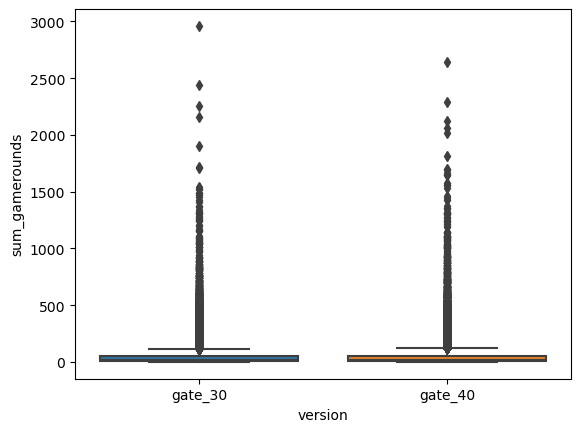

In [12]:
# There is still a lot of outliers!!
sns.boxplot(data=ab, y='sum_gamerounds', x='version', )

<a id='details'></a>
<h1 style="color:DarkSlateBlue" >5. SOME DETAILS</h1>

**The users installed the game but 3994 users never played the game!** Some reasons might explain this situation.

- They have no free time to play game
- Users might prefer to play other games or they play other games already
- Some users don't like the app etc.
- You can comment below for this users also

**The number of users decreases as the levels progress**

- Most of users played the game at early stage and they didn't progress.
- Tactile Entertainment should learn why users churn playing the game.
- Doing research and collecting data about the game and users would help to understand user churn
- The difficulty of the game can be measured
- Gifts might help player retention

Looking at the summary statistics, the control and Test groups seem similar, but are the two groups statistically significant? We will investigate this statistically.

In [29]:
# A/B Groups & Target Summary Stats
ab.groupby("version").sum_gamerounds.agg(["count", "median", "mean", "std", "max"])

,count,median,mean,std,max
version,,,,,
gate_30,44699,17.0,51.342111,102.057598,2961
gate_40,45489,16.0,51.298776,103.294416,2640


**Retention variables gives us player retention details.**

<li><code>retention_1</code> - did the player come back and play 1 day after installing?</li>
<li><code>retention_7</code> - did the player come back and play 7 days after installing?</li>

Also players tend not to play the game! There are many players who quit the game.

- 55 percent of the players didn't play the game 1 day after insalling
- 81 percent of the players didn't play the game 7 day after insalling

In [30]:
# Retention Problem
pd.DataFrame({"RET1_COUNT": ab["retention_1"].value_counts(),
              "RET7_COUNT": ab["retention_7"].value_counts(),
              "RET1_RATIO": ab["retention_1"].value_counts() / len(ab),
              "RET7_RATIO": ab["retention_7"].value_counts() / len(ab)})

,RET1_COUNT,RET7_COUNT,RET1_RATIO,RET7_RATIO
False,50035,73408,0.554786,0.813944
True,40153,16780,0.445214,0.186056


Looking at the summary statistics of retention variables by version and comparing with sum_gamerounds, there are similarities between groups. However, it will be more helpful to see if there is a statistically significant difference.

In [47]:
ab.groupby(["version", "retention_1"]).sum_gamerounds.agg(["count", "median", "mean", "std", "max"])

count  median       mean         std   max
version retention_1                                            
gate_30 False        24665     6.0  16.359092   36.528426  1072
        True         20034    48.0  94.411700  135.037697  2961
gate_40 False        25370     6.0  16.340402   35.925756  1241
        True         20119    49.0  95.381182  137.887256  2640

In [48]:
ab.groupby(["version", "retention_7"]).sum_gamerounds.agg(["count", "median", "mean", "std", "max"])

count  median        mean         std   max
version retention_7                                             
gate_30 False        36198    11.0   25.796508   43.316158   981
        True          8501   105.0  160.117516  179.358560  2961
gate_40 False        37210    11.0   25.856356   44.406112  2640
        True          8279   111.0  165.649837  183.792499  2294

Similar results are seen when the number of users who came and did not come 1 day and 7 days after the game was installing. Approximately 12.000 users among the total users played the game both 1 day and 7 days after installing the game. 14% of the total users include people who will continue the game in the future.

In [ ]:
ab["Retention"] = np.where((ab.retention_1 == True) & (ab.retention_7 == True), 1,0)
ab.groupby(["version", "Retention"])["sum_gamerounds"].agg(["count", "median", "mean", "std", "max"])

When the retention variables are combined and the two groups are compared, the summary statistics are similar here as well.

In [ ]:
ab["NewRetention"] = list(map(lambda x,y: str(x)+"-"+str(y), ab.retention_1, ab.retention_7))
ab.groupby(["version", "NewRetention"]).sum_gamerounds.agg(["count", "median", "mean", "std", "max"]).reset_index()

<a id='ab'></a>
<h1 style="color:DarkSlateBlue" >6. A/B Testing</h1>

### Assumptions:
- Check normality
- If Normal Distribution, check homogeneity

### Steps:
- Split & Define Control Group & Test Group
- Apply Shapiro Test for normality
- If parametric apply Levene Test for homogeneity of variances
- If Parametric + homogeneity of variances apply T-Test
- If Parametric - homogeneity of variances apply Welch Test
- If Non-parametric apply Mann Whitney U Test directly

In [49]:
# Define A/B groups
ab["version"] = np.where(ab.version == "gate_30", "A", "B")
ab.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,A,3,False,False
1,337,A,38,True,False
2,377,B,165,True,False
3,483,B,1,False,False
4,488,B,179,True,True


In [50]:
# A/B Testing Function - Quick Solution
def AB_Test(dataframe, group, target):
    
    # Packages
    from scipy.stats import shapiro
    import scipy.stats as stats
    
    # Split A/B
    groupA = dataframe[dataframe[group] == "A"][target]
    groupB = dataframe[dataframe[group] == "B"][target]
    
    # Assumption: Normality
    ntA = shapiro(groupA)[1] < 0.05
    ntB = shapiro(groupB)[1] < 0.05
    # H0: Distribution is Normal! - False
    # H1: Distribution is not Normal! - True
    
    if (ntA == False) & (ntB == False): # "H0: Normal Distribution"
        # Parametric Test
        # Assumption: Homogeneity of variances
        leveneTest = stats.levene(groupA, groupB)[1] < 0.05
        # H0: Homogeneity: False
        # H1: Heterogeneous: True
        
        if leveneTest == False:
            # Homogeneity
            ttest = stats.ttest_ind(groupA, groupB, equal_var=True)[1]
            # H0: M1 == M2 - False
            # H1: M1 != M2 - True
        else:
            # Heterogeneous
            ttest = stats.ttest_ind(groupA, groupB, equal_var=False)[1]
            # H0: M1 == M2 - False
            # H1: M1 != M2 - True
    else:
        # Non-Parametric Test
        ttest = stats.mannwhitneyu(groupA, groupB)[1] 
        # H0: M1 == M2 - False
        # H1: M1 != M2 - True
        
    # Result
    temp = pd.DataFrame({
        "AB Hypothesis":[ttest < 0.05], 
        "p-value":[ttest]
    })
    temp["Test Type"] = np.where((ntA == False) & (ntB == False), "Parametric", "Non-Parametric")
    temp["AB Hypothesis"] = np.where(temp["AB Hypothesis"] == False, "Fail to Reject H0", "Reject H0")
    temp["Comment"] = np.where(temp["AB Hypothesis"] == "Fail to Reject H0", "A/B groups are similar!", "A/B groups are not similar!")
    
    # Columns
    if (ntA == False) & (ntB == False):
        temp["Homogeneity"] = np.where(leveneTest == False, "Yes", "No")
        temp = temp[["Test Type", "Homogeneity","AB Hypothesis", "p-value", "Comment"]]
    else:
        temp = temp[["Test Type","AB Hypothesis", "p-value", "Comment"]]
    
    # Print Hypothesis
    print("# A/B Testing Hypothesis")
    print("H0: A == B")
    print("H1: A != B", "\n")
    
    return temp
    
    
    
# Apply A/B Testing
AB_Test(dataframe=ab, group = "version", target = "sum_gamerounds")

# A/B Testing Hypothesis
H0: A == B
H1: A != B 



,Test Type,AB Hypothesis,p-value,Comment
0,Non-Parametric,Fail to Reject H0,0.050892,A/B groups are similar!


<a id='conclusion'></a>
<h1 style="color:DarkSlateBlue" >7. Conclusion</h1>

### Remember business problem!

**As players progress through the game they will encounter gates that force them to wait some time before they can progress or make an in-app purchase. In this project, we will analyze the result of an A/B test where the first gate in Cookie Cats was moved from level 30 to level 40. In particular, we will analyze the impact on player retention and game rounds.**

Firstly, we investigated relationships and structures in the data. There was no missing value problem but was one outlier problem in the data. Summary stats and plots help us to understand the data and problem.

Before A/B Testing, we shared some details about game, players, problems and suggestion to our customer/director/ceo etc.

After applying A/B Testing, the analysis result gives us some important information. Shapiro Testing rejected H0 for Normality assumption. Therefore we needed to apply a Non-parametric test as called Mann Whitney U to compare two groups. As a result, Mann Whitney U Testing rejected H0 hypothesis and we learned A/B groups are not similar!

Briefly, There are statistically significant difference between two groups about moving first gate from level 30 to level 40 for game rounds. 

### Which level has more advantages in terms of player retention?

1-day and 7-day average retention are higher when the gate is at level 30 than when it is at level 40.

In [ ]:
ab.groupby("version").retention_1.mean(), ab.groupby("version").retention_7.mean()

The gate should be at level 30 but average retentions look like similar. We need more data for similarity.